## Наберите код создания сети обработки ирисов Фишера



In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import datasets
import pandas as pd

iris = datasets.load_iris()

In [2]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

ir = pd.DataFrame(iris.data, columns=iris.feature_names)
ir['target'] = iris.target

ir.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

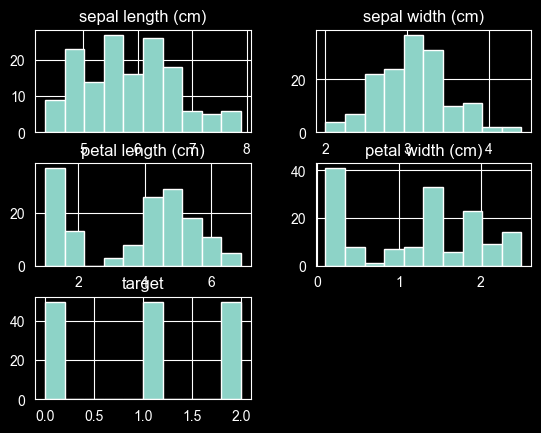

In [6]:
ir.hist()
plt.show()

<Axes: >

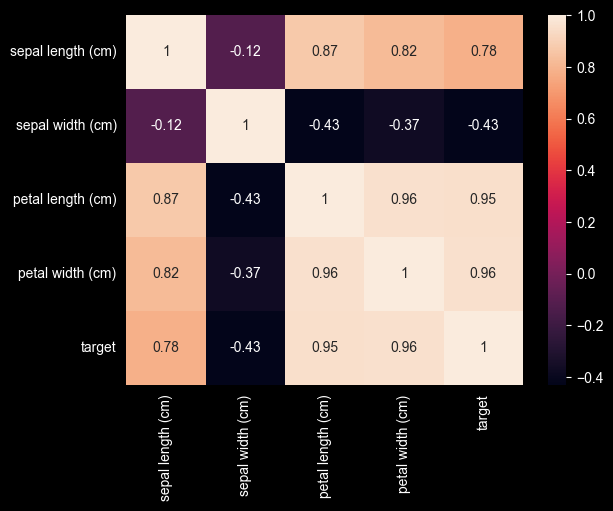

In [7]:
correlation_matrix = ir.corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True)

In [8]:
X_full  = pd.DataFrame(iris.data,columns=iris.feature_names)
Y_full = ir['target']
print(X_full.shape)
X_full.head()

(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
X_full.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [10]:
Y_full.head(100)

0     0
1     0
2     0
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    1
Name: target, Length: 100, dtype: int64

In [11]:
Y_full.shape

(150,)

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X_full, Y_full, test_size=0.15, random_state=42)

### предобработка

In [13]:
mean = X_train.mean(axis=0)
X_train -= mean
std = X_train.std(axis=0)
X_train /= std

X_test -= mean
X_test /= std

### Создаем сеть

In [14]:
from tensorflow import keras
model = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(3, activation='softmax'),
])


C:\Users\Daniil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
history = model.fit(X_train, Y_train,
                    batch_size=2,
                    epochs=20,
                    validation_split=0.2,
                    verbose = 1
                    )

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4653 - loss: 0.9902 - val_accuracy: 0.6154 - val_loss: 0.8467
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6238 - loss: 0.7465 - val_accuracy: 0.6923 - val_loss: 0.6967
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6931 - loss: 0.6342 - val_accuracy: 0.6923 - val_loss: 0.6190
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7129 - loss: 0.5685 - val_accuracy: 0.7308 - val_loss: 0.5705
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7129 - loss: 0.5227 - val_accuracy: 0.6923 - val_loss: 0.5371
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7327 - loss: 0.4898 - val_accuracy: 0.7308 - val_loss: 0.5110
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8317 - loss: 0.4635 - val_accuracy: 0.7308 - val_loss: 0.4875
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8119 - loss: 0.4436 - val_accuracy: 0.8077 - val_loss:

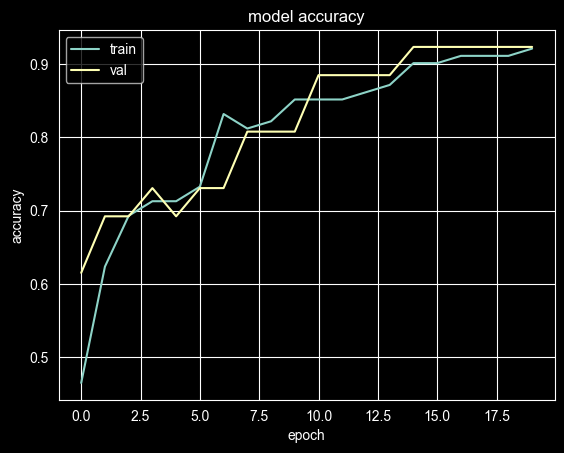

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

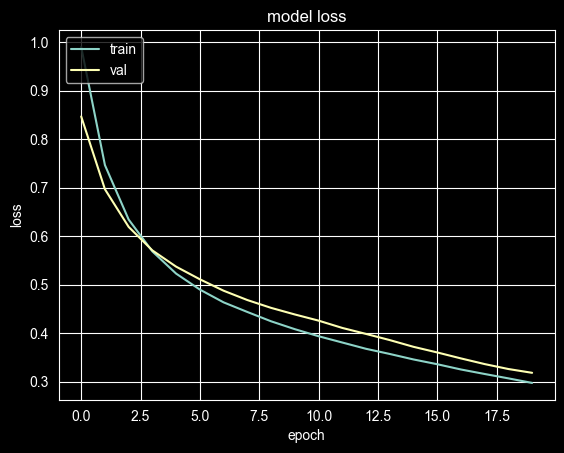

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [20]:
test_loss,test_acc = model.evaluate(X_test, Y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9130 - loss: 0.2936


In [21]:
prediction1 = model.predict(X_test)
prediction1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


array([[1.8109404e-02, 5.8434194e-01, 3.9754868e-01],
       [9.7244275e-01, 2.5346704e-02, 2.2105859e-03],
       [6.3302366e-05, 6.8078145e-02, 9.3185848e-01],
       [2.8030548e-02, 5.4148763e-01, 4.3048191e-01],
       [6.4504836e-03, 4.8114392e-01, 5.1240563e-01],
       [9.4613349e-01, 4.9383059e-02, 4.4834204e-03],
       [1.3175461e-01, 6.4036632e-01, 2.2787909e-01],
       [5.4100668e-03, 1.7997511e-01, 8.1461483e-01],
       [5.1070233e-03, 5.9098166e-01, 4.0391123e-01],
       [4.0891066e-02, 6.7054820e-01, 2.8856075e-01],
       [1.5728313e-02, 2.4659768e-01, 7.3767400e-01],
       [9.7274876e-01, 2.4836548e-02, 2.4146985e-03],
       [9.6878761e-01, 2.9164797e-02, 2.0476114e-03],
       [9.7293526e-01, 2.4725551e-02, 2.3391210e-03],
       [9.8720634e-01, 1.1668031e-02, 1.1256338e-03],
       [5.5838648e-02, 4.1487396e-01, 5.2928746e-01],
       [3.5843302e-03, 1.5586890e-01, 8.4054679e-01],
       [4.0810883e-02, 6.8312073e-01, 2.7606839e-01],
       [3.4623031e-02, 6.097

## Постройте матрицу ошибок, выведите значения метрик

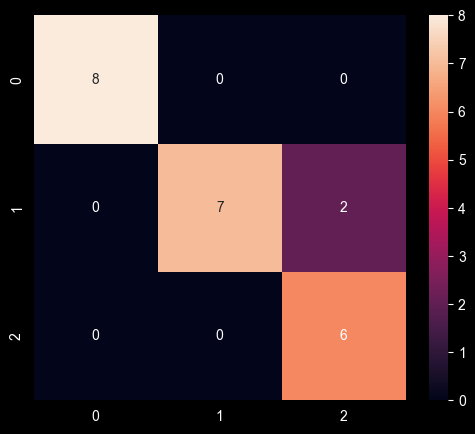

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(prediction1, axis=1)

cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True)
plt.show()

## Попробуйте другие параметры оптимизаторов, метрик, другихструктур сетей

In [23]:
import matplotlib.pyplot as plt
from tensorflow import keras

# Конфигурации: (оптимизатор, слои, dropout)
configs = [
    (keras.optimizers.SGD(learning_rate=0.01), [8], 0.0),
    ('adam', [8], 0.0),
    ('adam', [16, 8], 0.2)
]

histories = []

for opt, layers, drop in configs:
    model = keras.Sequential()
    model.add(keras.layers.Dense(layers[0], activation='relu', input_shape=(X_train.shape[1],)))
    if drop:
        model.add(keras.layers.Dropout(drop))
    for u in layers[1:]:
        model.add(keras.layers.Dense(u, activation='relu'))
        if drop:
            model.add(keras.layers.Dropout(drop))
    model.add(keras.layers.Dense(3, activation='softmax'))

    model.compile(opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, Y_train, epochs=30, batch_size=8, validation_split=0.2, verbose=0)
    histories.append(history)


C:\Users\Daniil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Daniil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Daniil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first la

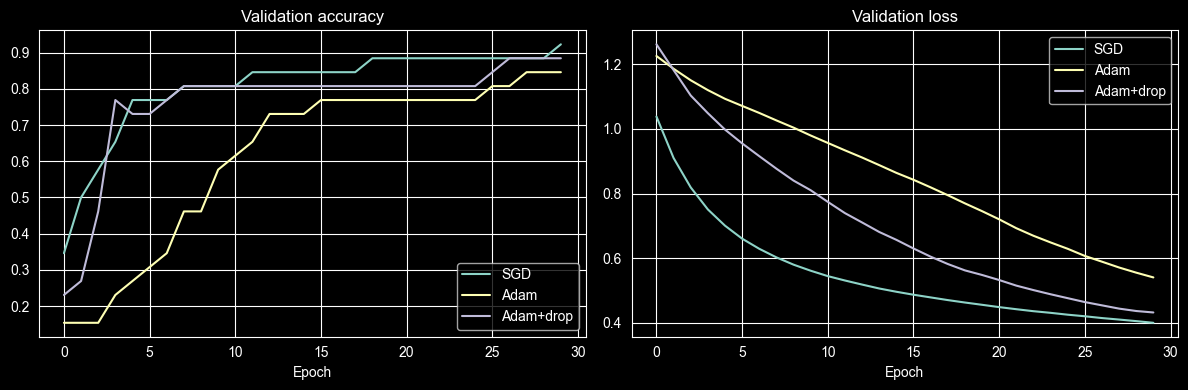

In [24]:

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for i, hist in enumerate(histories):
    plt.plot(hist.history['val_accuracy'], label=['SGD','Adam','Adam+drop'][i])
plt.title('Validation accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
for i, hist in enumerate(histories):
    plt.plot(hist.history['val_loss'], label=['SGD','Adam','Adam+drop'][i])
plt.title('Validation loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

## Увеличьте количество признаков и постройте сеть (увеличьтеколичество слоёв)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from tensorflow import keras

iris = load_iris()
X, Y = iris.data, iris.target

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_poly, Y, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Глубокая сеть (4 скрытых слоя)
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, Y_train, epochs=50, batch_size=8, validation_split=0.2, verbose=0)


C:\Users\Daniil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Сравните результаты

In [26]:
## Сравните результаты

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_simple = np.argmax(prediction1, axis=1)
acc_simple = accuracy_score(Y_test, y_pred_simple)

y_pred_poly = np.argmax(model.predict(X_test), axis=1)
acc_poly = accuracy_score(Y_test, y_pred_poly)

cm_simple = confusion_matrix(Y_test, y_pred_simple)
cm_poly = confusion_matrix(Y_test, y_pred_poly)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


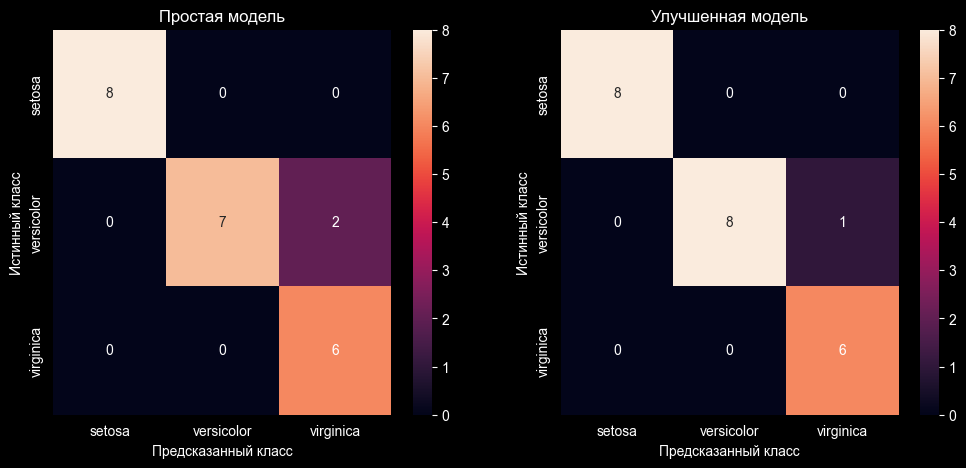

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       1.00      0.89      0.94         9
   virginica       0.86      1.00      0.92         6

    accuracy                           0.96        23
   macro avg       0.95      0.96      0.95        23
weighted avg       0.96      0.96      0.96        23



In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_simple, annot=True,
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[0])
axes[0].set_title('Простая модель')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

sns.heatmap(cm_poly, annot=True,
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[1])
axes[1].set_title('Улучшенная модель')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.show()

print(classification_report(Y_test, y_pred_poly, target_names=iris.target_names))

## Постройте модели НС для ваших задач из лабораторныхработ7и 8. Сравните результаты с полученными ранее

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from tensorflow import keras

df = pd.read_csv("data/lab07-data.csv", encoding='cp1251')
df = df.dropna(axis=1, how='all').copy()

df['target'] = pd.qcut(df['total'], q=3, duplicates='drop').cat.codes
df = df.dropna().copy()

X = df.drop(['target', 'total'], axis=1).copy()
y = df['target'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X_train.columns.difference(cat_cols).tolist()

preprocess = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', 'passthrough', num_cols)
])

models = {
    'LogReg': Pipeline([
        ('prep', preprocess),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'Tree': Pipeline([
        ('prep', preprocess),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'RF': Pipeline([
        ('prep', preprocess),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'KNN': Pipeline([
        ('prep', preprocess),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([name, accuracy_score(y_test, pred)])

X_train_nn = preprocess.fit_transform(X_train)
X_test_nn = preprocess.transform(X_test)

scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_test_nn = scaler.transform(X_test_nn)

n_classes = y.nunique()

nn = keras.Sequential([
    keras.layers.Input(shape=(X_train_nn.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(n_classes, activation='softmax')
])

nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn.fit(X_train_nn, y_train, epochs=20, batch_size=16, verbose=0)

nn_pred = np.argmax(nn.predict(X_test_nn, verbose=0), axis=1)
nn_acc = accuracy_score(y_test, nn_pred)

results.append(['NeuralNet', nn_acc])

results = pd.DataFrame(results, columns=['Модель', 'Accuracy']).sort_values(
    by='Accuracy', ascending=False
)

results

,Модель,Accuracy
1,Tree,0.999216
2,RF,0.998824
4,NeuralNet,0.936091
0,LogReg,0.907273
3,KNN,0.641247


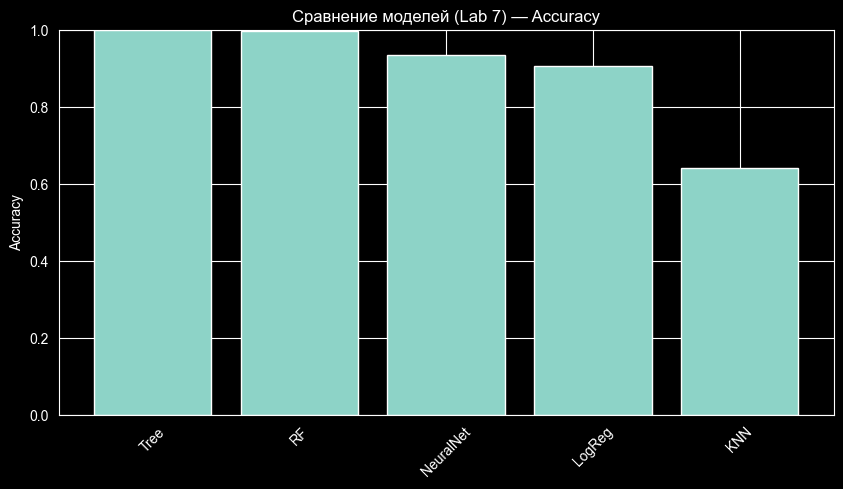

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(results['Модель'], results['Accuracy'])
plt.title('Сравнение моделей (Lab 7) — Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.show()

In [30]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, accuracy_score

train = pd.read_csv('train_preprocessed.csv')

X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
acc_lr = accuracy_score(y_test, (y_pred_lr >= 0.5).astype(int))

ridge_cv = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='neg_root_mean_squared_error'
)
ridge_cv.fit(X_train, y_train)
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
acc_ridge = accuracy_score(y_test, (y_pred_ridge >= 0.5).astype(int))

scaler = None
X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_test_nn = scaler.transform(X_test_nn)

nn_titanic = keras.Sequential([
    keras.layers.Input(shape=(X_train_nn.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

nn_titanic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_titanic.fit(
    X_train_nn, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

y_pred_nn_prob = nn_titanic.predict(X_test_nn, verbose=0).flatten()
y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)

rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn_prob))
acc_nn = accuracy_score(y_test, y_pred_nn)

results_titanic = pd.DataFrame({
    'Модель': ['LinearRegression', 'Ridge', 'NeuralNetwork'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_nn],
    'Accuracy': [acc_lr, acc_ridge, acc_nn]
})

results_titanic

,Модель,RMSE,Accuracy
0,LinearRegression,0.363673,0.787709
1,Ridge,0.363614,0.787709
2,NeuralNetwork,0.356739,0.815642


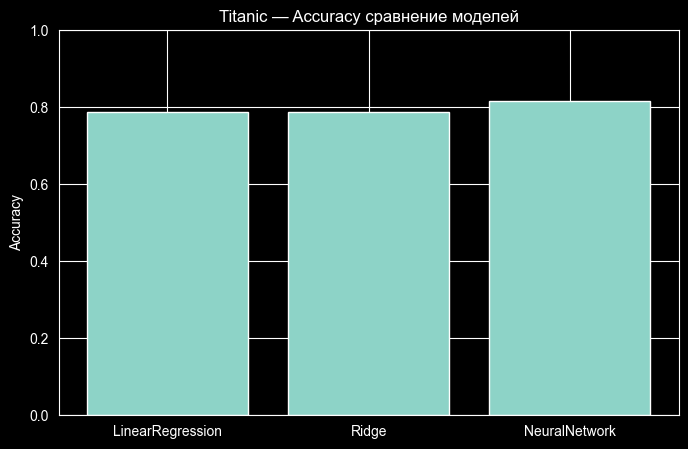

In [31]:
plt.figure(figsize=(8,5))

plt.bar(results_titanic['Модель'], results_titanic['Accuracy'])
plt.title('Titanic — Accuracy сравнение моделей')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()

In [33]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=21),
    'Gradient Boosting': GradientBoostingRegressor(random_state=21),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

base_results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    base_results.append([name, rmse, r2])

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_gb.fit(X_train_scaled, y_train)
best_gb = grid_gb.best_estimator_

param_grid_svr = {
    'kernel': ['rbf'],
    'C': [0.5, 1, 2],
    'gamma': ['scale', 'auto']
}
grid_svr = GridSearchCV(
    SVR(),
    param_grid_svr,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_svr.fit(X_train_scaled, y_train)
best_svr = grid_svr.best_estimator_

param_grid_knn = {
    'n_neighbors': [5, 7, 9],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_

voting_reg = VotingRegressor([
    ('rf', best_rf),
    ('gb', best_gb),
    ('svr', best_svr),
    ('knn', best_knn),
    ('lr', LinearRegression())
])
voting_reg.fit(X_train_scaled, y_train)
y_pred_vote = voting_reg.predict(X_test_scaled)
rmse_vote = np.sqrt(mean_squared_error(y_test, y_pred_vote))
r2_vote = r2_score(y_test, y_pred_vote)

nn_housing = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

nn_housing.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

nn_housing.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_pred_nn = nn_housing.predict(X_test_scaled, verbose=0).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

results_housing = pd.DataFrame({
    'Модель': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'SVR',
        'KNN',
        'VotingRegressor',
        'NeuralNetwork'
    ],
    'RMSE': [
        base_results[0][1],
        base_results[1][1],
        base_results[2][1],
        base_results[3][1],
        base_results[4][1],
        rmse_vote,
        rmse_nn
    ],
    'R2': [
        base_results[0][2],
        base_results[1][2],
        base_results[2][2],
        base_results[3][2],
        base_results[4][2],
        r2_vote,
        r2_nn
    ]
})

results_housing.sort_values('RMSE')

,Модель,RMSE,R2
1,Random Forest,0.504922,0.805445
6,NeuralNetwork,0.519537,0.794019
5,VotingRegressor,0.540543,0.777026
2,Gradient Boosting,0.542234,0.775629
3,SVR,0.597498,0.727563
4,KNN,0.657588,0.670010
0,Linear Regression,0.745581,0.575788


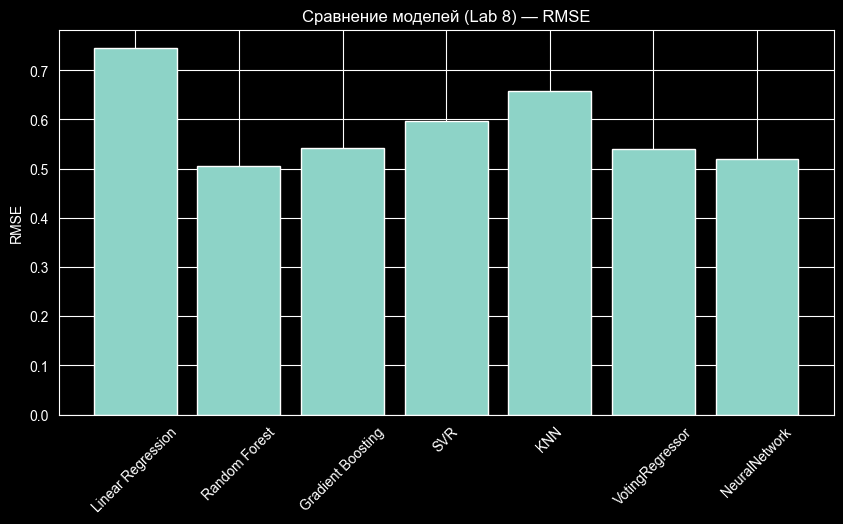

In [34]:
plt.figure(figsize=(10,5))

plt.bar(results_housing['Модель'], results_housing['RMSE'])
plt.title('Сравнение моделей (Lab 8) — RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=45)

plt.show()